# Social Network Advertisement Purchase Prediction

* Objective: To predict whether a customer will purchase a product based on their age and salary.

In [167]:
# Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [178]:
# Load Dataset
df=pd.read_csv(r"C:\Users\gaura\Downloads\archive (3)\Social_Network_Ads.csv")
df.head()

# Purchased = 0 → No
# Purchased = 1 → Yes

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


# Understand Data

In [102]:
print('shape :- ',df.shape)
print('size :-',df.size)
print()
df.info()

shape :-  (400, 3)
size :- 1200

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [103]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Data Cleaning

In [104]:
print(df.isnull().sum())
print()
print('duplicate:- ',df.duplicated().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

duplicate:-  33


In [147]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Data Visualization

In [148]:
df.value_counts().sum()

np.int64(367)

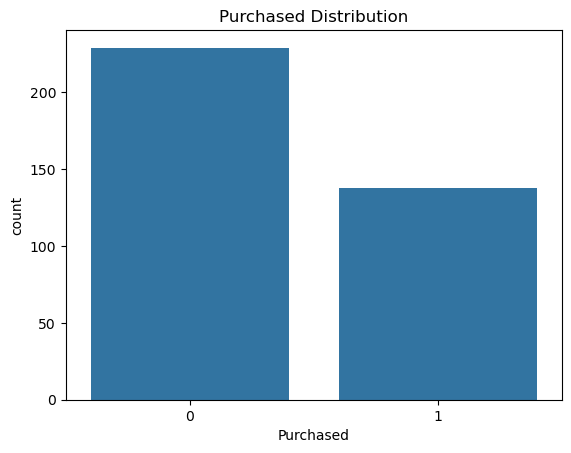

In [149]:
sns.countplot(x='Purchased',data=df)
plt.title('Purchased Distribution')
plt.show()

In [150]:
# This count plot shows that more customers did not purchase the product (0) , compared to customers who purchased the product (1).

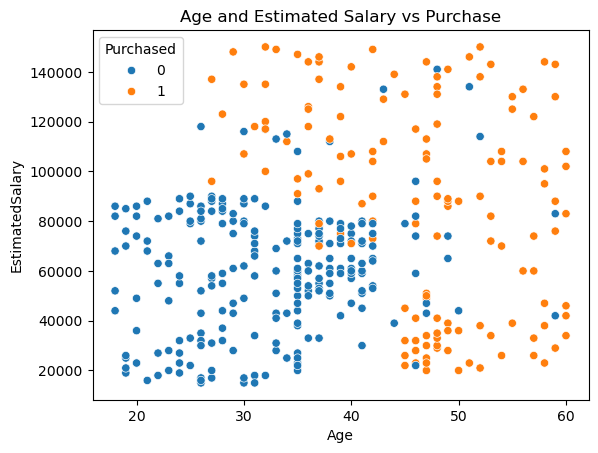

In [151]:
sns.scatterplot(x='Age',y='EstimatedSalary',hue='Purchased',data=df)
plt.title('Age and Estimated Salary vs Purchase')
plt.show()

In [152]:
# This scatter plot show older age more purchased the product and aslo , while salary not clearly determine the purchased decision

# Seperate the Data in indepedent and depedent

In [153]:
x=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [154]:
df['Purchased'].value_counts() #This data is not balanced because we can se the value count of category 

Purchased
0    229
1    138
Name: count, dtype: int64

# Train Test Split

In [161]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

print(x_train.shape)
print(x_test.shape)

scale=StandardScaler()

x_train_sc=scale.fit_transform(x_train)
x_test_sc=scale.transform(x_test)

model=SVC()
model.fit(x_train_sc,y_train)

(275, 2)
(92, 2)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Confusion Matrix, Classification Report & Prediction

In [173]:
y_pred=model.predict(x_test_sc)
print('accurcy:- ',accuracy_score(y_test,y_pred))
print('Precision:- ',precision_score(y_test,y_pred)) 
print('Recall:- ',recall_score(y_test,y_pred))
print('F1:- ',f1_score(y_test,y_pred))

accurcy:-  0.9130434782608695
Precision:-  0.868421052631579
Recall:-  0.9166666666666666
F1:-  0.8918918918918919


In [212]:
# Our data is a little unbalanced, so we check
# Accuracy, Precision, Recall, and F1-score.
# We do not depend only on Accuracy.

In [175]:
print(confusion_matrix(y_test,y_pred))

[[51  5]
 [ 3 33]]


In [176]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93        56
           1       0.87      0.92      0.89        36

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92



# ************************************************************************************

# SVM Kernel

# ************************************************************************************

# Linear Kernel

In [186]:
# Linear Kernel
model_l=SVC(kernel='linear')
model_l.fit(x_train_sc,y_train)
y_pred_l=model_l.predict(x_test_sc)
print('accurcy:- ',accuracy_score(y_test,y_pred_l))
print('Precision:- ',precision_score(y_test,y_pred_l)) 
print('Recall:- ',recall_score(y_test,y_pred_l))
print('F1:- ',f1_score(y_test,y_pred_l))

accurcy:-  0.8695652173913043
Precision:-  0.8529411764705882
Recall:-  0.8055555555555556
F1:-  0.8285714285714286


In [187]:
print(classification_report(y_test,y_pred_l))
print()
print(confusion_matrix(y_test,y_pred_l))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        56
           1       0.85      0.81      0.83        36

    accuracy                           0.87        92
   macro avg       0.87      0.86      0.86        92
weighted avg       0.87      0.87      0.87        92


[[51  5]
 [ 7 29]]


# RBF Kernel

In [188]:
# RBF
model_rbf=SVC(kernel='rbf')
model_rbf.fit(x_train_sc,y_train)
y_pred_rbf=model_rbf.predict(x_test_sc)
print('accurcy:- ',accuracy_score(y_test,y_pred_rbf))
print('Precision:- ',precision_score(y_test,y_pred_rbf)) 
print('Recall:- ',recall_score(y_test,y_pred_rbf))
print('F1:- ',f1_score(y_test,y_pred_rbf))

accurcy:-  0.9130434782608695
Precision:-  0.868421052631579
Recall:-  0.9166666666666666
F1:-  0.8918918918918919


In [194]:
print(classification_report(y_test,y_pred_rbf))
print()
print(confusion_matrix(y_test,y_pred_rbf))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93        56
           1       0.87      0.92      0.89        36

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92


[[51  5]
 [ 3 33]]


# Polynomial Kernel

In [195]:
#Polynomial
model_poly=SVC(kernel='poly')
model_poly.fit(x_train_sc,y_train)
y_pred_poly=model_poly.predict(x_test_sc)
print('accurcy:- ',accuracy_score(y_test,y_pred_poly))
print('Precision:- ',precision_score(y_test,y_pred_poly)) 
print('Recall:- ',recall_score(y_test,y_pred_poly))
print('F1:- ',f1_score(y_test,y_pred_poly))

accurcy:-  0.8695652173913043
Precision:-  0.9285714285714286
Recall:-  0.7222222222222222
F1:-  0.8125


In [196]:
print(classification_report(y_test,y_pred_poly))
print()
print(confusion_matrix(y_test,y_pred_poly))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90        56
           1       0.93      0.72      0.81        36

    accuracy                           0.87        92
   macro avg       0.89      0.84      0.86        92
weighted avg       0.88      0.87      0.87        92


[[54  2]
 [10 26]]


# Sigmoid Kernel

In [193]:
# Sigmoid
model_sig=SVC(kernel='sigmoid')
model_sig.fit(x_train_sc,y_train)
y_pred_sig=model_sig.predict(x_test_sc)
print('accurcy:- ',accuracy_score(y_test,y_pred_sig))
print('Precision:- ',precision_score(y_test,y_pred_sig)) 
print('Recall:- ',recall_score(y_test,y_pred_sig))
print('F1:- ',f1_score(y_test,y_pred_sig))

accurcy:-  0.6739130434782609
Precision:-  0.5714285714285714
Recall:-  0.6666666666666666
F1:-  0.6153846153846154


In [197]:
print(classification_report(y_test,y_pred_sig))
print()
print(confusion_matrix(y_test,y_pred_sig))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        56
           1       0.57      0.67      0.62        36

    accuracy                           0.67        92
   macro avg       0.67      0.67      0.67        92
weighted avg       0.69      0.67      0.68        92


[[38 18]
 [12 24]]


# Overfitting & Underfitting

In [213]:
y_pred_train=model.predict(x_train_sc)
y_pred_test=model.predict(x_test_sc)

print('Train accuracy :- ',accuracy_score(y_train,y_pred_train))
print('Test accuracy :- ',accuracy_score(y_test,y_pred_test))

# Train and test accuracy are almost the same, so our model is working well and is not overfitting.

Train accuracy :-  0.9054545454545454
Test accuracy :-  0.9130434782608695


# Cross Validation

In [211]:
cv_score=cross_val_score(model,x_train_sc,y_train,cv=5,scoring='recall')
cv_score

array([0.9       , 0.85      , 0.9       , 0.9047619 , 0.95238095])